In [1]:
from google.colab import files
import pandas as pd

# Upload CSV file
uploaded = files.upload()

# Read CSV file into DataFrame after uploading
for filename in uploaded.keys():
  df = pd.read_csv(filename)
  print(f"File '{filename}' uploaded and read successfully.")
  break # Process only the first file if multiple files are uploaded

Saving facebook_reviews.csv to facebook_reviews.csv
File 'facebook_reviews.csv' uploaded and read successfully.


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355744 entries, 0 to 355743
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              355744 non-null  object
 1   userName              355741 non-null  object
 2   content               355710 non-null  object
 3   score                 355744 non-null  int64 
 4   thumbsUpCount         355744 non-null  int64 
 5   reviewCreatedVersion  293264 non-null  object
 6   at                    355744 non-null  object
 7   appVersion            293264 non-null  object
dtypes: int64(2), object(6)
memory usage: 21.7+ MB


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,b290c064-f2af-4509-b425-0b6a1bca51a9,Angela Larsen,all these new updates are causing so many glit...,2,10,556.1.0.63.64,2026-04-20 04:01:19,556.1.0.63.64
1,b03e2730-8311-4dab-80e3-a6447013913d,Angelle Rivera,"Some post are missing, please fix the system. ...",1,3,556.1.0.63.64,2026-04-16 01:58:34,556.1.0.63.64
2,16db6557-41b3-470b-9cfd-b960fbb52bb8,Westerson Pakyntein,This is the worst app ever. I have changed my ...,1,4,555.0.0.49.59,2026-04-13 05:04:50,555.0.0.49.59
3,09ea8f0a-a833-439b-9323-224c101a41f0,Janet H Brasher,love Facebook. enjoy reading and seeing lots o...,2,1,555.0.0.49.59,2026-04-09 05:32:58,555.0.0.49.59
4,69629bec-26c0-4c1a-82c9-ab37e9c68a8b,Shawn Poirier,"everything is fine , just getting the hang of ...",5,5,554.0.0.57.70,2026-04-05 07:30:05,554.0.0.57.70


/tmp/ipykernel_1295/2786306999.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score', data=df, palette='viridis')


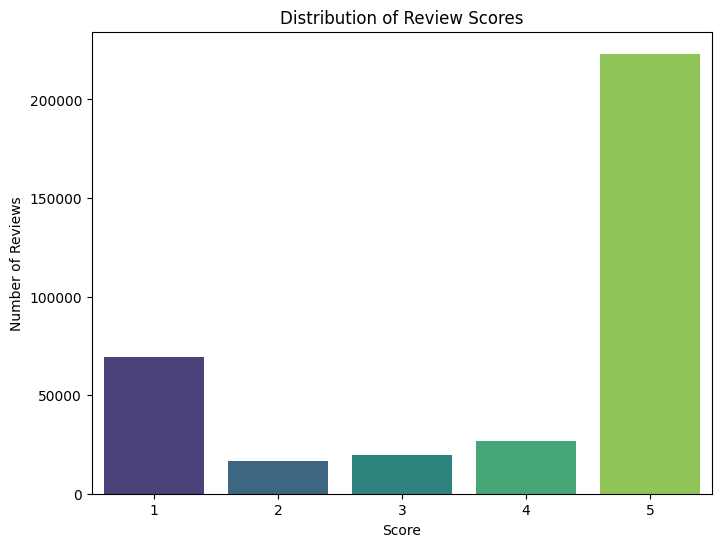

In [4]:
plt.figure(figsize=(8, 6))
sns.countplot(x='score', data=df, palette='viridis')
plt.title('Distribution of Review Scores')
plt.xlabel('Score')
plt.ylabel('Number of Reviews')
plt.show()

In [5]:
# Define hyperparameters
VOCAB_SIZE = 10000  # Based on common practice, can be tuned
MAX_LENGTH = 100    # Maximum length of sequences, can be tuned
EMBEDDING_DIM = 128 # Dimension of the word embeddings

# Handle potential missing text content
df['content'] = df['content'].fillna('')

# Tokenize the text
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['content'])

word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique tokens.")

sequences = tokenizer.texts_to_sequences(df['content'])

# Pad the sequences
padded_sequences = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

# Prepare the target variable
# Assuming scores are 1-5, convert to 0-4 for categorical classification
labels = np.array(df['score'] - 1)

print(f"Shape of padded sequences: {padded_sequences.shape}")
print(f"Shape of labels: {labels.shape}")

Found 134881 unique tokens.
Shape of padded sequences: (355744, 100)
Shape of labels: (355744,)


In [6]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (284595, 100), y_train shape: (284595,)
X_test shape: (71149, 100), y_test shape: (71149,)


In [7]:
model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LENGTH),
    LSTM(128),
    Dropout(0.5), # Add dropout for regularization
    Dense(5, activation='softmax') # 5 output classes (scores 1-5, mapped to 0-4)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

With the model defined, let's train it using our training data. We'll also monitor its performance on the test data.

In [9]:
NUM_EPOCHS = 20 # Can be tuned
BATCH_SIZE = 32 # Can be tuned

history = model.fit(
    X_train,
    y_train,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test)
)

Epoch 1/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 93s 10ms/step - accuracy: 0.7463 - loss: 0.8365 - val_accuracy: 0.7439 - val_loss: 0.8382
Epoch 2/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 92s 10ms/step - accuracy: 0.7496 - loss: 0.8175 - val_accuracy: 0.7443 - val_loss: 0.8365
Epoch 3/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 92s 10ms/step - accuracy: 0.7538 - loss: 0.8016 - val_accuracy: 0.7434 - val_loss: 0.8422
Epoch 4/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 140s 10ms/step - accuracy: 0.7580 - loss: 0.7858 - val_accuracy: 0.7396 - val_loss: 0.8540
Epoch 5/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 94s 11ms/step - accuracy: 0.7630 - loss: 0.7703 - val_accuracy: 0.7382 - val_loss: 0.8609
Epoch 6/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 139s 10ms/step - accuracy: 0.7687 - loss: 0.7545 - val_accuracy: 0.7335 - val_loss: 0.8726
Epoch 7/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 93s 10ms/step - accuracy: 0.7737 - loss: 0.7394 - val_accuracy: 0.7333 - val_loss: 0.8870
Epoch 8/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 91s 10ms/step - accuracy: 0.7794

In [10]:
import pandas as pd

# Create a DataFrame from the history dictionary
history_df = pd.DataFrame(history.history)

# Display the first few rows of the history DataFrame
print("Training History DataFrame:")
display(history_df.head())

# Save the history DataFrame to a CSV file
history_csv_filename = 'rnn_training_history.csv'
history_df.to_csv(history_csv_filename, index=False)

print(f"\nTraining history saved to '{history_csv_filename}'")
print("You can download this file from the Colab file browser (left sidebar -> folder icon).")

Training History DataFrame:


,accuracy,loss,val_accuracy,val_loss
0,0.746278,0.836495,0.743890,0.838239
1,0.749613,0.817503,0.744297,0.836510
2,0.753840,0.801587,0.743370,0.842199
3,0.758021,0.785832,0.739645,0.854035
4,0.763039,0.770320,0.738183,0.860903



Training history saved to 'rnn_training_history.csv'
You can download this file from the Colab file browser (left sidebar -> folder icon).


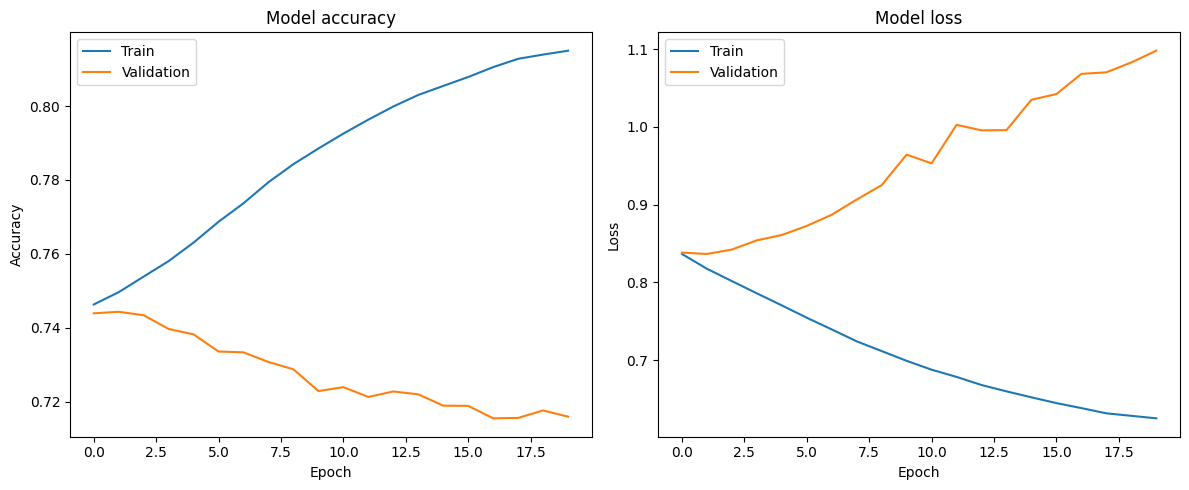

In [11]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()